# Optimized OpenACC GPU benchmarks (2026-05-19)

Post-optimization (`test_after_opt`) IQ-TREE3 runs on three GPUs — **A100**, **V100**, **H200** — for AA `LG+I+G4` and DNA `GTR+I+G4` at 100k and 1M sites, 100 taxa.

Data source: `/Users/u7826985/Projects/Nvidia/results/2026_05_19_opt_results`

Baseline for comparison: `/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_10_master_cputests/cpu_vs_gpu_combined.csv` — same workloads on master-branch IQ-TREE3 (pre-optimization) plus CPU runs on CLX (Cascade Lake, NCI `normal`) and SPR (Sapphire Rapids, NCI `normalsr`).

Questions answered:
1. **Optimization speedup** — opt-GPU wall-time vs the May-10 baseline GPU wall-time, per cell.
2. **Opt-GPU vs best CPU** — does the optimized OpenACC build beat the fastest CPU config?
3. **Log-likelihood agreement** — does the optimized GPU still converge to the same lnL?

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OPT_ROOT  = '/Users/u7826985/Projects/Nvidia/results/2026_05_19_opt_results'
BASELINE  = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_10_master_cputests/cpu_vs_gpu_combined.csv'
OUT_DIR   = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_19_opt_results'

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 11})

GPU_COLORS = {
    'V100': '#F2A900',
    'A100': '#1F78B4',
    'H200': '#76B900',
}
GPU_ORDER  = ['V100', 'A100', 'H200']

## 1. Parse the optimized GPU `.log` files

Same regex fields used by the May-10 parser: total wall-clock, total CPU time, tree-search wall/CPU, best lnL, iteration count.

In [2]:
FIELDS = {
    'wall_total_sec':      r'Total wall-clock time used:\s+([\d.]+)\s+sec',
    'cpu_total_sec':       r'Total CPU time used:\s+([\d.]+)\s+sec',
    'wall_treesearch_sec': r'Wall-clock time used for tree search:\s+([\d.]+)\s+sec',
    'cpu_treesearch_sec':  r'CPU time used for tree search:\s+([\d.]+)\s+sec',
    'best_lnl':            r'BEST SCORE FOUND\s*:\s*([-\d.]+)',
    'iterations':          r'Total number of iterations:\s+(\d+)',
}

def parse_log(path):
    txt = open(path).read()
    rec = {'filename': os.path.basename(path)}
    for key, pat in FIELDS.items():
        m = re.search(pat, txt)
        rec[key] = float(m.group(1)) if m else np.nan
    return rec

def gpu_from_name(fname):
    # Match the prefix `output_<gpu>_` so substrings like "taxa100" don't confuse A100/V100.
    f = fname.lower()
    if f.startswith('output_h200_'): return 'H200'
    if f.startswith('output_v100_'): return 'V100'
    if f.startswith('output_a100_'): return 'A100'
    return None

rows = []
for path in sorted(glob.glob(os.path.join(OPT_ROOT, '*', 'len_*', 'output_*.log'))):
    parts    = path.split(os.sep)
    datatype = parts[-3]
    length   = int(parts[-2].split('_')[1])
    gpu      = gpu_from_name(os.path.basename(path))
    if gpu is None: continue
    rec = parse_log(path)
    rec.update(dict(data_type=datatype, length=length, gpu=gpu))
    rows.append(rec)

opt = pd.DataFrame(rows)
opt['wall_total_min']      = opt['wall_total_sec']      / 60.0
opt['wall_treesearch_min'] = opt['wall_treesearch_sec'] / 60.0
opt = opt.sort_values(['data_type', 'length', 'gpu']).reset_index(drop=True)
opt[['data_type', 'length', 'gpu', 'wall_total_sec', 'wall_treesearch_sec', 'best_lnl', 'iterations']]

,data_type,length,gpu,wall_total_sec,wall_treesearch_sec,best_lnl,iterations
0,AA,100000,A100,2116.696,1516.194,-7.541977e+06,102.0
1,AA,100000,H200,1289.222,930.025,-7.541977e+06,102.0
2,AA,100000,V100,2594.952,1843.033,-7.541977e+06,102.0
3,AA,1000000,A100,17991.352,12698.446,-7.860520e+07,102.0
4,AA,1000000,H200,12160.531,8857.070,-7.860520e+07,102.0
5,AA,1000000,V100,33600.214,26782.879,-7.860520e+07,102.0
6,DNA,100000,A100,776.271,396.237,-5.692985e+06,102.0
7,DNA,100000,H200,470.986,247.062,-5.692985e+06,102.0
8,DNA,100000,V100,911.262,510.268,-5.692985e+06,102.0
9,DNA,1000000,A100,3852.509,2141.864,-5.920802e+07,102.0


## 2. Load the May-10 baseline

From `cpu_vs_gpu_combined.csv`. Split into baseline-GPU and CPU subsets.

In [3]:
base = pd.read_csv(BASELINE)

gpu_baseline = base[base['kind'] == 'GPU'].copy()
gpu_baseline['gpu'] = gpu_baseline['hardware'].str.replace('GPU_', '', regex=False)

cpu_baseline = base[base['kind'] == 'CPU'].copy()

# Best CPU config per (data_type, length): minimum wall_total_sec
best_cpu = (cpu_baseline
            .dropna(subset=['wall_total_sec'])
            .sort_values('wall_total_sec')
            .drop_duplicates(['data_type', 'length'], keep='first')
            [['data_type', 'length', 'config_label', 'wall_total_sec', 'best_lnl']]
            .rename(columns={'config_label': 'best_cpu_config',
                             'wall_total_sec': 'best_cpu_wall_sec',
                             'best_lnl': 'best_cpu_lnl'}))
best_cpu = best_cpu.sort_values(['data_type', 'length']).reset_index(drop=True)
best_cpu

,data_type,length,best_cpu_config,best_cpu_wall_sec,best_cpu_lnl
0,AA,10000,SPR 48T,372.432,-8.073500e+05
1,AA,100000,SPR 104T,1424.306,-7.541977e+06
2,AA,1000000,SPR 104T,29235.971,-7.860520e+07
3,DNA,10000,SPR 10T,103.923,-5.642088e+05
4,DNA,100000,SPR 104T,518.547,-5.692985e+06
5,DNA,1000000,SPR 104T,5012.118,-5.920802e+07


## 3. Optimization speedup — opt GPU vs baseline GPU

For each (datatype, length, gpu) cell: `baseline_wall / opt_wall`. >1 means the optimization made the GPU run faster.

In [4]:
cmp_gpu = opt.merge(
    gpu_baseline[['data_type', 'length', 'gpu', 'wall_total_sec', 'wall_treesearch_sec', 'best_lnl']]
        .rename(columns={'wall_total_sec':      'baseline_wall_sec',
                         'wall_treesearch_sec': 'baseline_tree_sec',
                         'best_lnl':            'baseline_lnl'}),
    on=['data_type', 'length', 'gpu'], how='left')

cmp_gpu = cmp_gpu.rename(columns={'wall_total_sec':      'opt_wall_sec',
                                   'wall_treesearch_sec': 'opt_tree_sec',
                                   'best_lnl':            'opt_lnl'})
cmp_gpu['speedup_total']     = cmp_gpu['baseline_wall_sec'] / cmp_gpu['opt_wall_sec']
cmp_gpu['speedup_treesearch']= cmp_gpu['baseline_tree_sec'] / cmp_gpu['opt_tree_sec']
cmp_gpu['lnl_diff']          = cmp_gpu['opt_lnl'] - cmp_gpu['baseline_lnl']

cmp_gpu_out = cmp_gpu[['data_type', 'length', 'gpu',
                       'baseline_wall_sec', 'opt_wall_sec', 'speedup_total',
                       'baseline_tree_sec', 'opt_tree_sec', 'speedup_treesearch',
                       'baseline_lnl', 'opt_lnl', 'lnl_diff']]
cmp_gpu_out.to_csv(os.path.join(OUT_DIR, 'opt_vs_baseline_gpu.csv'), index=False)
cmp_gpu_out.round(3)

,data_type,length,gpu,baseline_wall_sec,opt_wall_sec,speedup_total,baseline_tree_sec,opt_tree_sec,speedup_treesearch,baseline_lnl,opt_lnl,lnl_diff
0,AA,100000,A100,2272.027,2116.696,1.073,1644.446,1516.194,1.085,-7.541977e+06,-7.541977e+06,0.0
1,AA,100000,H200,1367.078,1289.222,1.060,991.076,930.025,1.066,-7.541977e+06,-7.541977e+06,0.0
2,AA,100000,V100,2905.543,2594.952,1.120,2065.578,1843.033,1.121,-7.541977e+06,-7.541977e+06,0.0
3,AA,1000000,A100,NaN,17991.352,NaN,NaN,12698.446,NaN,NaN,-7.860520e+07,NaN
4,AA,1000000,H200,12197.809,12160.531,1.003,8698.133,8857.070,0.982,-7.860520e+07,-7.860520e+07,0.0
5,AA,1000000,V100,NaN,33600.214,NaN,NaN,26782.879,NaN,NaN,-7.860520e+07,NaN
6,DNA,100000,A100,958.752,776.271,1.235,540.329,396.237,1.364,-5.692985e+06,-5.692985e+06,0.0
7,DNA,100000,H200,516.057,470.986,1.096,298.090,247.062,1.207,-5.692985e+06,-5.692985e+06,0.0
8,DNA,100000,V100,1000.451,911.262,1.098,581.892,510.268,1.140,-5.692985e+06,-5.692985e+06,0.0
9,DNA,1000000,A100,4523.878,3852.509,1.174,2472.475,2141.864,1.154,-5.920802e+07,-5.920802e+07,0.0


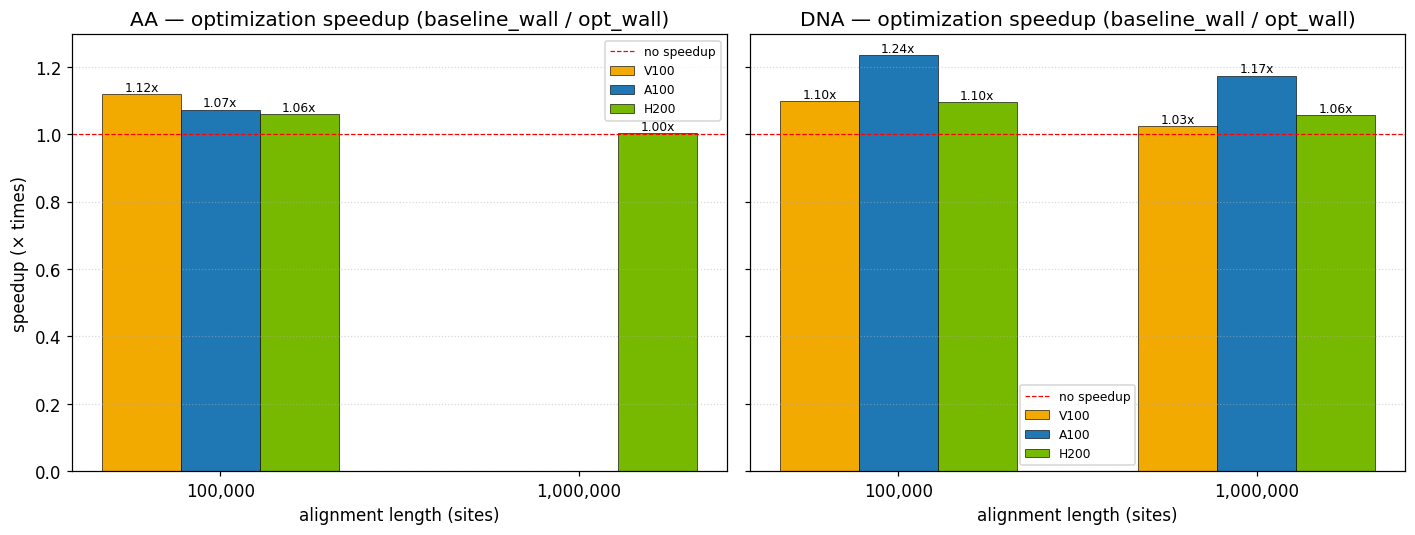

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
lengths = sorted(cmp_gpu['length'].unique())
x       = np.arange(len(lengths))
width   = 0.22
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = cmp_gpu[cmp_gpu['data_type'] == dt]
    for i, gpu in enumerate(GPU_ORDER):
        offsets = (i - 1) * width
        vals, positions = [], []
        for j, L in enumerate(lengths):
            r = sub[(sub['length'] == L) & (sub['gpu'] == gpu)]
            if r.empty or pd.isna(r['speedup_total'].iloc[0]): continue
            vals.append(r['speedup_total'].iloc[0])
            positions.append(x[j] + offsets)
        if not vals: continue
        bars = ax.bar(positions, vals, width, color=GPU_COLORS[gpu],
                      edgecolor='black', linewidth=0.4, label=gpu)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}x',
                    ha='center', va='bottom', fontsize=8)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, label='no speedup')
    ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in lengths])
    ax.set_xlabel('alignment length (sites)')
    ax.set_title(f'{dt} — optimization speedup (baseline_wall / opt_wall)')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel('speedup (× times)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'opt_speedup_total.png'), bbox_inches='tight')
plt.show()

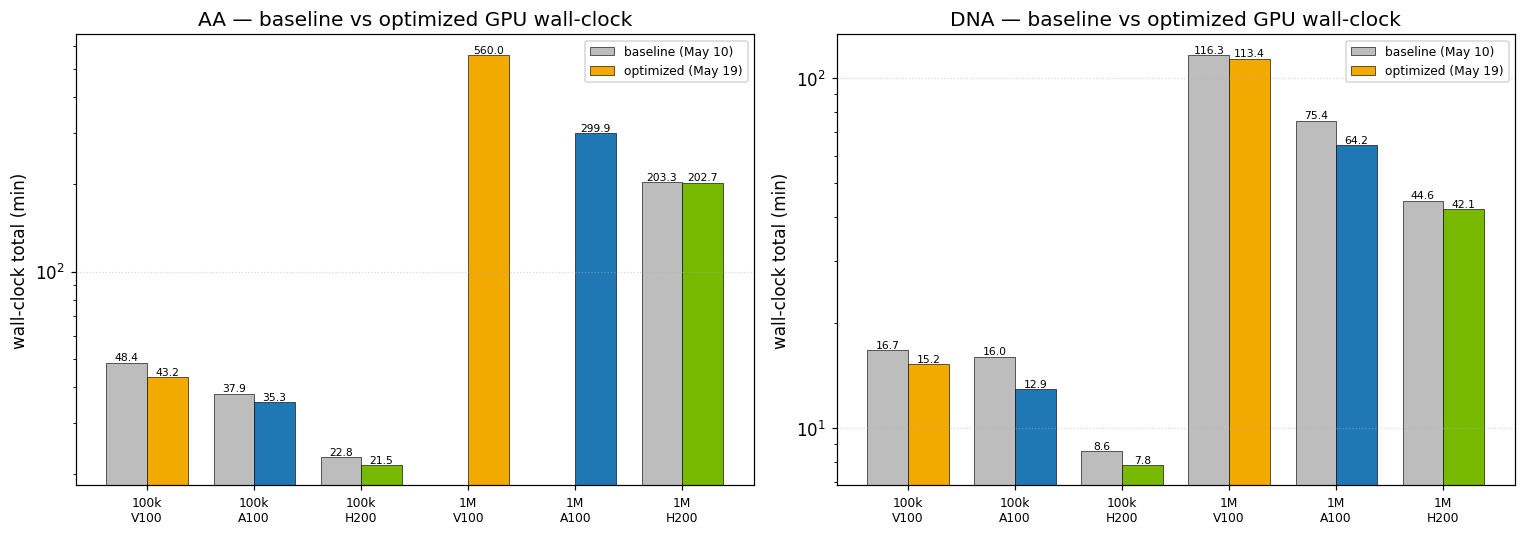

In [6]:
# Side-by-side bars: baseline wall vs opt wall, per (gpu, length), one panel per datatype
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lengths = sorted(cmp_gpu['length'].unique())
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = cmp_gpu[cmp_gpu['data_type'] == dt].sort_values(['length', 'gpu'])
    labels, base_vals, opt_vals, colors = [], [], [], []
    for L in lengths:
        for gpu in GPU_ORDER:
            r = sub[(sub['length'] == L) & (sub['gpu'] == gpu)]
            if r.empty: continue
            labels.append(f'{L//1000}k\n{gpu}' if L < 1_000_000 else f'1M\n{gpu}')
            base_vals.append(r['baseline_wall_sec'].iloc[0] / 60.0)
            opt_vals.append(r['opt_wall_sec'].iloc[0] / 60.0)
            colors.append(GPU_COLORS[gpu])
    xp = np.arange(len(labels))
    w = 0.38
    bb = ax.bar(xp - w/2, base_vals, w, color='#BDBDBD', edgecolor='black',
                linewidth=0.4, label='baseline (May 10)')
    bo = ax.bar(xp + w/2, opt_vals,  w, color=colors,    edgecolor='black',
                linewidth=0.4, label='optimized (May 19)')
    for b, v in zip(bb, base_vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    for b, v in zip(bo, opt_vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(xp); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('wall-clock total (min)')
    ax.set_yscale('log')
    ax.set_title(f'{dt} — baseline vs optimized GPU wall-clock')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'baseline_vs_opt_wall.png'), bbox_inches='tight')
plt.show()

## 4. Optimized GPU vs best CPU config (from May-10 dataset)

Best CPU = whichever (CLX / SPR, thread count) finished fastest for that cell on master-branch. The opt-GPU number is the new May-19 wall-clock.

In [7]:
vs_cpu = opt.merge(best_cpu, on=['data_type', 'length'], how='left')
vs_cpu['gpu_speedup_vs_best_cpu'] = vs_cpu['best_cpu_wall_sec'] / vs_cpu['wall_total_sec']
vs_cpu_out = vs_cpu[['data_type', 'length', 'gpu', 'wall_total_sec',
                     'best_cpu_config', 'best_cpu_wall_sec', 'gpu_speedup_vs_best_cpu',
                     'best_lnl', 'best_cpu_lnl']]
vs_cpu_out.to_csv(os.path.join(OUT_DIR, 'opt_gpu_vs_best_cpu.csv'), index=False)
vs_cpu_out.round(3)

,data_type,length,gpu,wall_total_sec,best_cpu_config,best_cpu_wall_sec,gpu_speedup_vs_best_cpu,best_lnl,best_cpu_lnl
0,AA,100000,A100,2116.696,SPR 104T,1424.306,0.673,-7.541977e+06,-7.541977e+06
1,AA,100000,H200,1289.222,SPR 104T,1424.306,1.105,-7.541977e+06,-7.541977e+06
2,AA,100000,V100,2594.952,SPR 104T,1424.306,0.549,-7.541977e+06,-7.541977e+06
3,AA,1000000,A100,17991.352,SPR 104T,29235.971,1.625,-7.860520e+07,-7.860520e+07
4,AA,1000000,H200,12160.531,SPR 104T,29235.971,2.404,-7.860520e+07,-7.860520e+07
5,AA,1000000,V100,33600.214,SPR 104T,29235.971,0.870,-7.860520e+07,-7.860520e+07
6,DNA,100000,A100,776.271,SPR 104T,518.547,0.668,-5.692985e+06,-5.692985e+06
7,DNA,100000,H200,470.986,SPR 104T,518.547,1.101,-5.692985e+06,-5.692985e+06
8,DNA,100000,V100,911.262,SPR 104T,518.547,0.569,-5.692985e+06,-5.692985e+06
9,DNA,1000000,A100,3852.509,SPR 104T,5012.118,1.301,-5.920802e+07,-5.920802e+07


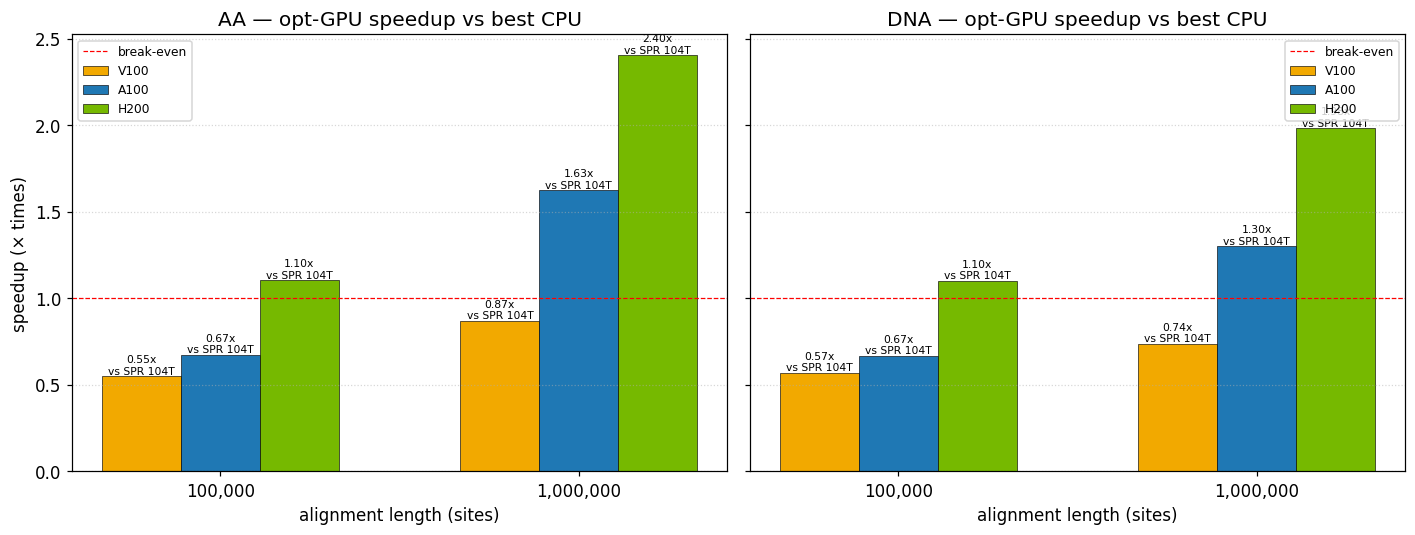

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
lengths = sorted(vs_cpu['length'].unique())
x       = np.arange(len(lengths))
width   = 0.22
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub = vs_cpu[vs_cpu['data_type'] == dt]
    for i, gpu in enumerate(GPU_ORDER):
        offsets = (i - 1) * width
        vals, positions, cpu_labels = [], [], []
        for j, L in enumerate(lengths):
            r = sub[(sub['length'] == L) & (sub['gpu'] == gpu)]
            if r.empty: continue
            v = r['gpu_speedup_vs_best_cpu'].iloc[0]
            if pd.isna(v): continue
            vals.append(v)
            positions.append(x[j] + offsets)
            cpu_labels.append(r['best_cpu_config'].iloc[0])
        if not vals: continue
        bars = ax.bar(positions, vals, width, color=GPU_COLORS[gpu],
                      edgecolor='black', linewidth=0.4, label=gpu)
        for b, v, c in zip(bars, vals, cpu_labels):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}x\nvs {c}',
                    ha='center', va='bottom', fontsize=7)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, label='break-even')
    ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in lengths])
    ax.set_xlabel('alignment length (sites)')
    ax.set_title(f'{dt} — opt-GPU speedup vs best CPU')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel('speedup (× times)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'opt_gpu_vs_best_cpu.png'), bbox_inches='tight')
plt.show()

## 5. Log-likelihood agreement

The optimization should preserve numerical convergence. Plot `|opt_lnL − baseline_lnL|` and `|opt_lnL − best_cpu_lnL|` per cell.

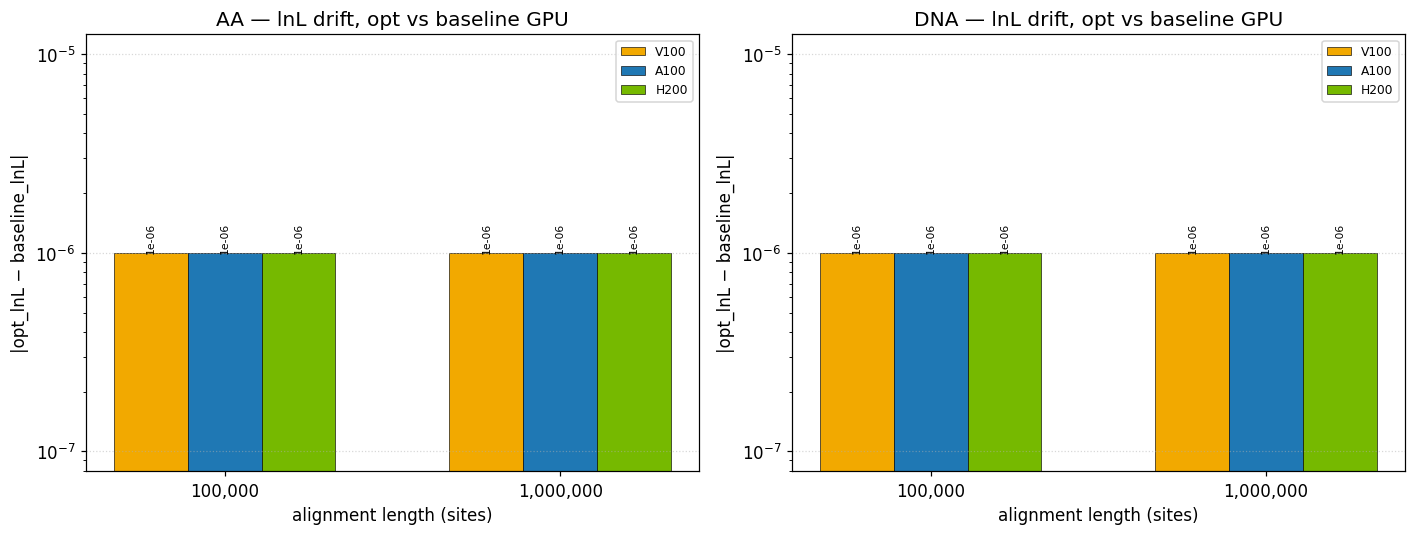

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lengths = sorted(cmp_gpu['length'].unique())
x       = np.arange(len(lengths))
width   = 0.22
for ax, dt in zip(axes, ['AA', 'DNA']):
    sub_gpu = cmp_gpu[cmp_gpu['data_type'] == dt]
    for i, gpu in enumerate(GPU_ORDER):
        offsets = (i - 1) * width
        vals, positions = [], []
        for j, L in enumerate(lengths):
            r = sub_gpu[(sub_gpu['length'] == L) & (sub_gpu['gpu'] == gpu)]
            if r.empty: continue
            d = abs(r['lnl_diff'].iloc[0])
            if pd.isna(d) or d == 0: d = 1e-6
            vals.append(d); positions.append(x[j] + offsets)
        if not vals: continue
        bars = ax.bar(positions, vals, width, color=GPU_COLORS[gpu],
                      edgecolor='black', linewidth=0.4, label=gpu)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.0e}',
                    ha='center', va='bottom', fontsize=7, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels([f'{L:,}' for L in lengths])
    ax.set_xlabel('alignment length (sites)')
    ax.set_ylabel('|opt_lnL − baseline_lnL|')
    ax.set_yscale('log')
    ax.set_title(f'{dt} — lnL drift, opt vs baseline GPU')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'opt_lnl_agreement.png'), bbox_inches='tight')
plt.show()

## 6. Summary table

Wall-clock (minutes) per cell, baseline GPU → opt GPU → speedup vs best CPU.

In [10]:
summary = cmp_gpu.merge(best_cpu, on=['data_type', 'length'], how='left')
summary['baseline_wall_min'] = summary['baseline_wall_sec'] / 60.0
summary['opt_wall_min']      = summary['opt_wall_sec']      / 60.0
summary['best_cpu_wall_min'] = summary['best_cpu_wall_sec'] / 60.0
summary['speedup_vs_best_cpu'] = summary['best_cpu_wall_sec'] / summary['opt_wall_sec']
out_cols = ['data_type', 'length', 'gpu',
            'baseline_wall_min', 'opt_wall_min', 'speedup_total',
            'best_cpu_config', 'best_cpu_wall_min', 'speedup_vs_best_cpu',
            'opt_lnl', 'baseline_lnl', 'best_cpu_lnl']
summary_out = summary[out_cols].sort_values(['data_type', 'length', 'gpu']).reset_index(drop=True)
summary_out.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False)
summary_out.round(3)

,data_type,length,gpu,baseline_wall_min,opt_wall_min,speedup_total,best_cpu_config,best_cpu_wall_min,speedup_vs_best_cpu,opt_lnl,baseline_lnl,best_cpu_lnl
0,AA,100000,A100,37.867,35.278,1.073,SPR 104T,23.738,0.673,-7.541977e+06,-7.541977e+06,-7.541977e+06
1,AA,100000,H200,22.785,21.487,1.060,SPR 104T,23.738,1.105,-7.541977e+06,-7.541977e+06,-7.541977e+06
2,AA,100000,V100,48.426,43.249,1.120,SPR 104T,23.738,0.549,-7.541977e+06,-7.541977e+06,-7.541977e+06
3,AA,1000000,A100,NaN,299.856,NaN,SPR 104T,487.266,1.625,-7.860520e+07,NaN,-7.860520e+07
4,AA,1000000,H200,203.297,202.676,1.003,SPR 104T,487.266,2.404,-7.860520e+07,-7.860520e+07,-7.860520e+07
5,AA,1000000,V100,NaN,560.004,NaN,SPR 104T,487.266,0.870,-7.860520e+07,NaN,-7.860520e+07
6,DNA,100000,A100,15.979,12.938,1.235,SPR 104T,8.642,0.668,-5.692985e+06,-5.692985e+06,-5.692985e+06
7,DNA,100000,H200,8.601,7.850,1.096,SPR 104T,8.642,1.101,-5.692985e+06,-5.692985e+06,-5.692985e+06
8,DNA,100000,V100,16.674,15.188,1.098,SPR 104T,8.642,0.569,-5.692985e+06,-5.692985e+06,-5.692985e+06
9,DNA,1000000,A100,75.398,64.208,1.174,SPR 104T,83.535,1.301,-5.920802e+07,-5.920802e+07,-5.920802e+07


## 7. Combined comparison — speed_cpus CPU configs + baseline GPUs + new opt GPUs

Same bar layout as `2026_05_17_speed_cpus/fig02_wall_treesearch.png`, with the new May-19 opt-GPU runs added side-by-side with their baseline counterparts. Hatched bars are the optimized build.

In [11]:
SPEED_CPUS_CSV = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_05_17_speed_cpus/combined_runs.csv'

cpu_gpu = pd.read_csv(SPEED_CPUS_CSV)

# Append the new opt-GPU runs (May 19) with distinct config labels
opt_rows = opt[['data_type', 'length', 'gpu',
                'wall_total_sec', 'wall_treesearch_sec',
                'wall_total_min', 'wall_treesearch_min',
                'best_lnl', 'iterations']].copy()
LENGTH_LABEL = {100000: '100K', 1000000: '1M', 10000000: '10M'}
opt_rows['length_label'] = opt_rows['length'].map(LENGTH_LABEL)
opt_rows['hw']           = opt_rows['gpu']
opt_rows['threads']      = 1
opt_rows['build']        = 'GPU opt'
opt_rows['config_label'] = 'GPU ' + opt_rows['gpu'] + ' opt'
opt_rows = opt_rows.drop(columns=['gpu'])

combined = pd.concat([cpu_gpu, opt_rows], ignore_index=True)
combined.to_csv(os.path.join(OUT_DIR, 'combined_with_opt.csv'), index=False)
combined.tail(15)

,data_type,length,length_label,hw,threads,build,config_label,wall_total_sec,wall_treesearch_sec,wall_total_min,wall_treesearch_min,best_lnl,iterations
36,DNA,1000000,1M,H200,1.0,GPU,GPU H200,2673.447,1571.067,44.557450,26.184450,-5.920802e+07,102.0
37,DNA,1000000,1M,V100,1.0,GPU,GPU V100,6975.073,4102.941,116.251217,68.382350,-5.920802e+07,102.0
38,DNA,10000000,10M,H200,1.0,GPU,GPU H200,50416.102,26118.849,840.268367,435.314150,-5.789538e+08,102.0
39,AA,100000,100K,A100,1.0,GPU opt,GPU A100 opt,2116.696,1516.194,35.278267,25.269900,-7.541977e+06,102.0
40,AA,100000,100K,H200,1.0,GPU opt,GPU H200 opt,1289.222,930.025,21.487033,15.500417,-7.541977e+06,102.0
41,AA,100000,100K,V100,1.0,GPU opt,GPU V100 opt,2594.952,1843.033,43.249200,30.717217,-7.541977e+06,102.0
42,AA,1000000,1M,A100,1.0,GPU opt,GPU A100 opt,17991.352,12698.446,299.855867,211.640767,-7.860520e+07,102.0
43,AA,1000000,1M,H200,1.0,GPU opt,GPU H200 opt,12160.531,8857.070,202.675517,147.617833,-7.860520e+07,102.0
44,AA,1000000,1M,V100,1.0,GPU opt,GPU V100 opt,33600.214,26782.879,560.003567,446.381317,-7.860520e+07,102.0
45,DNA,100000,100K,A100,1.0,GPU opt,GPU A100 opt,776.271,396.237,12.937850,6.603950,-5.692985e+06,102.0


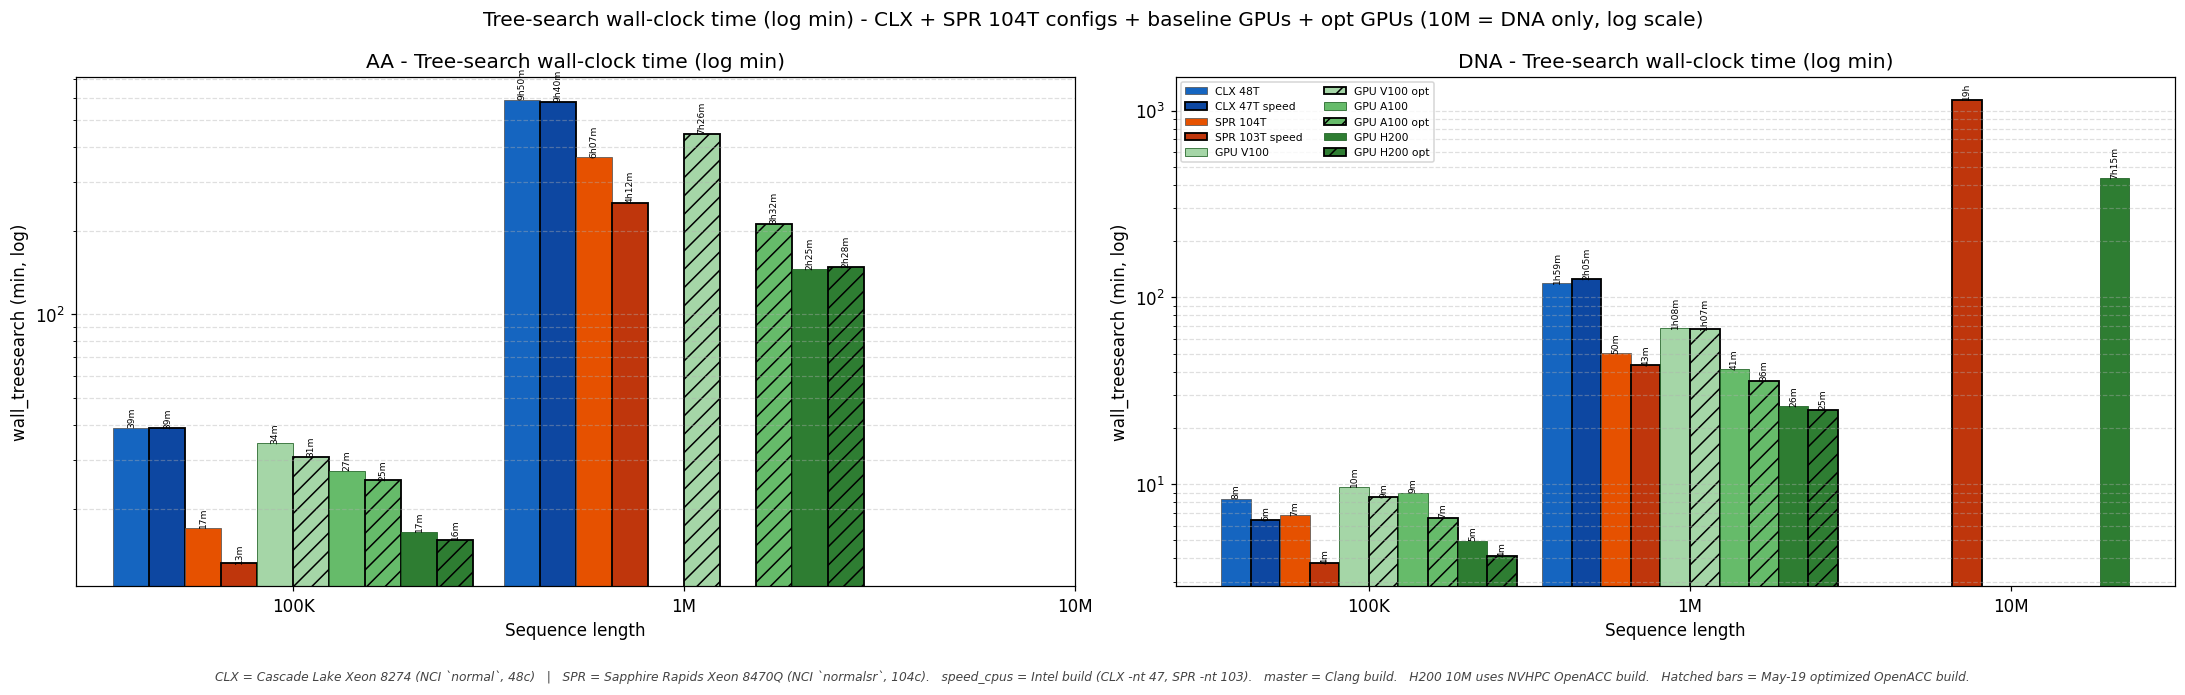

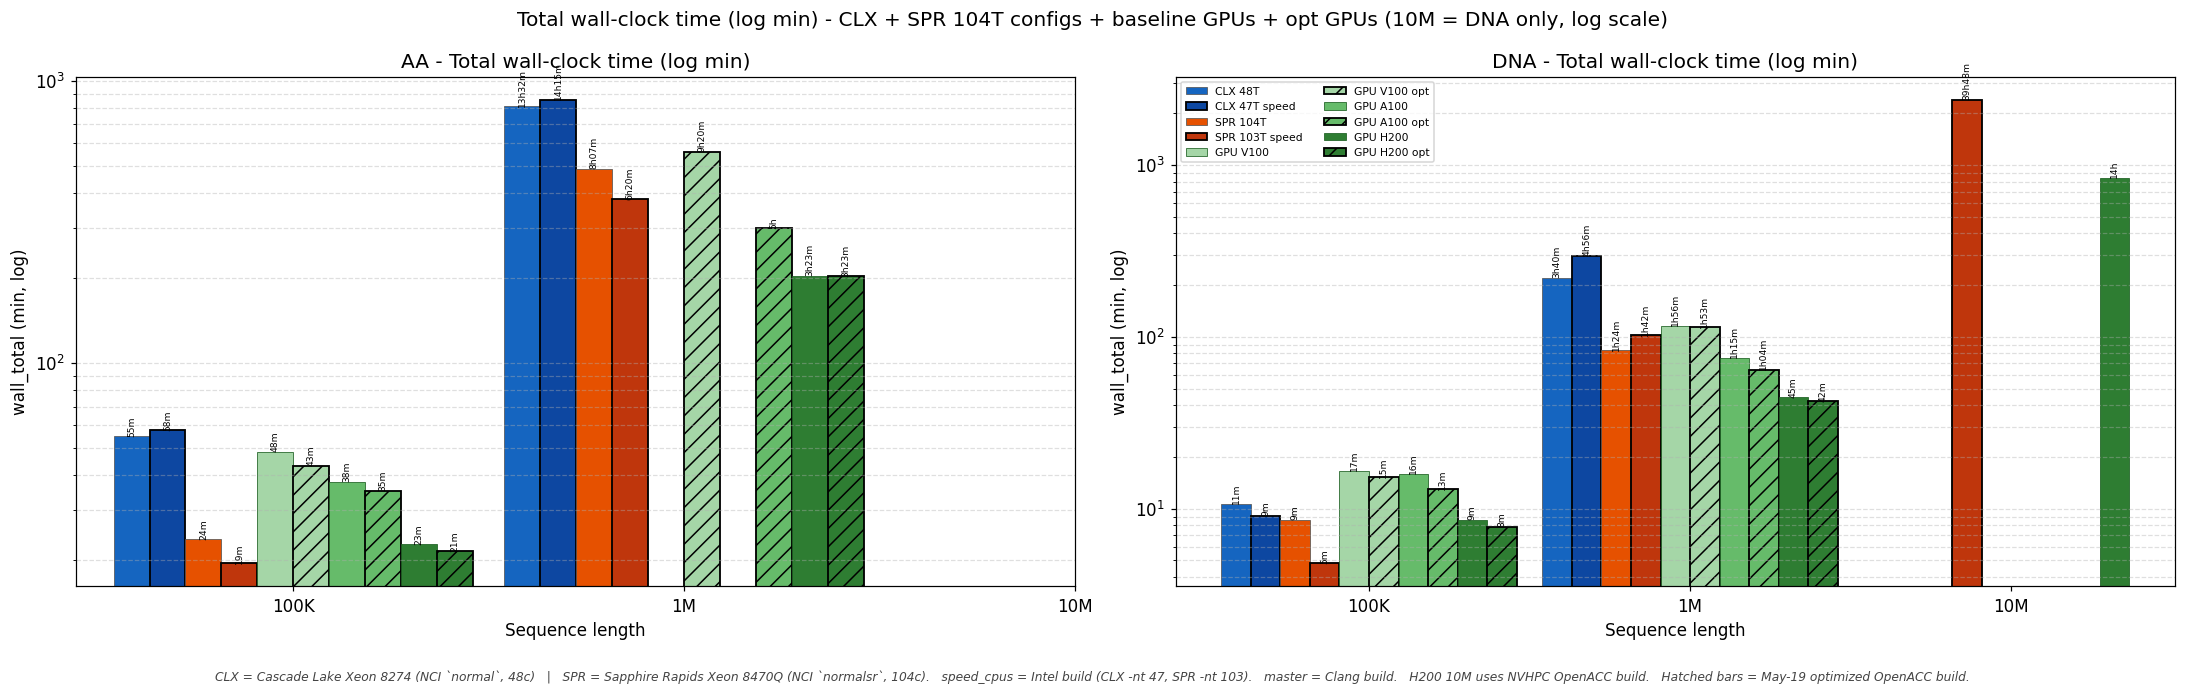

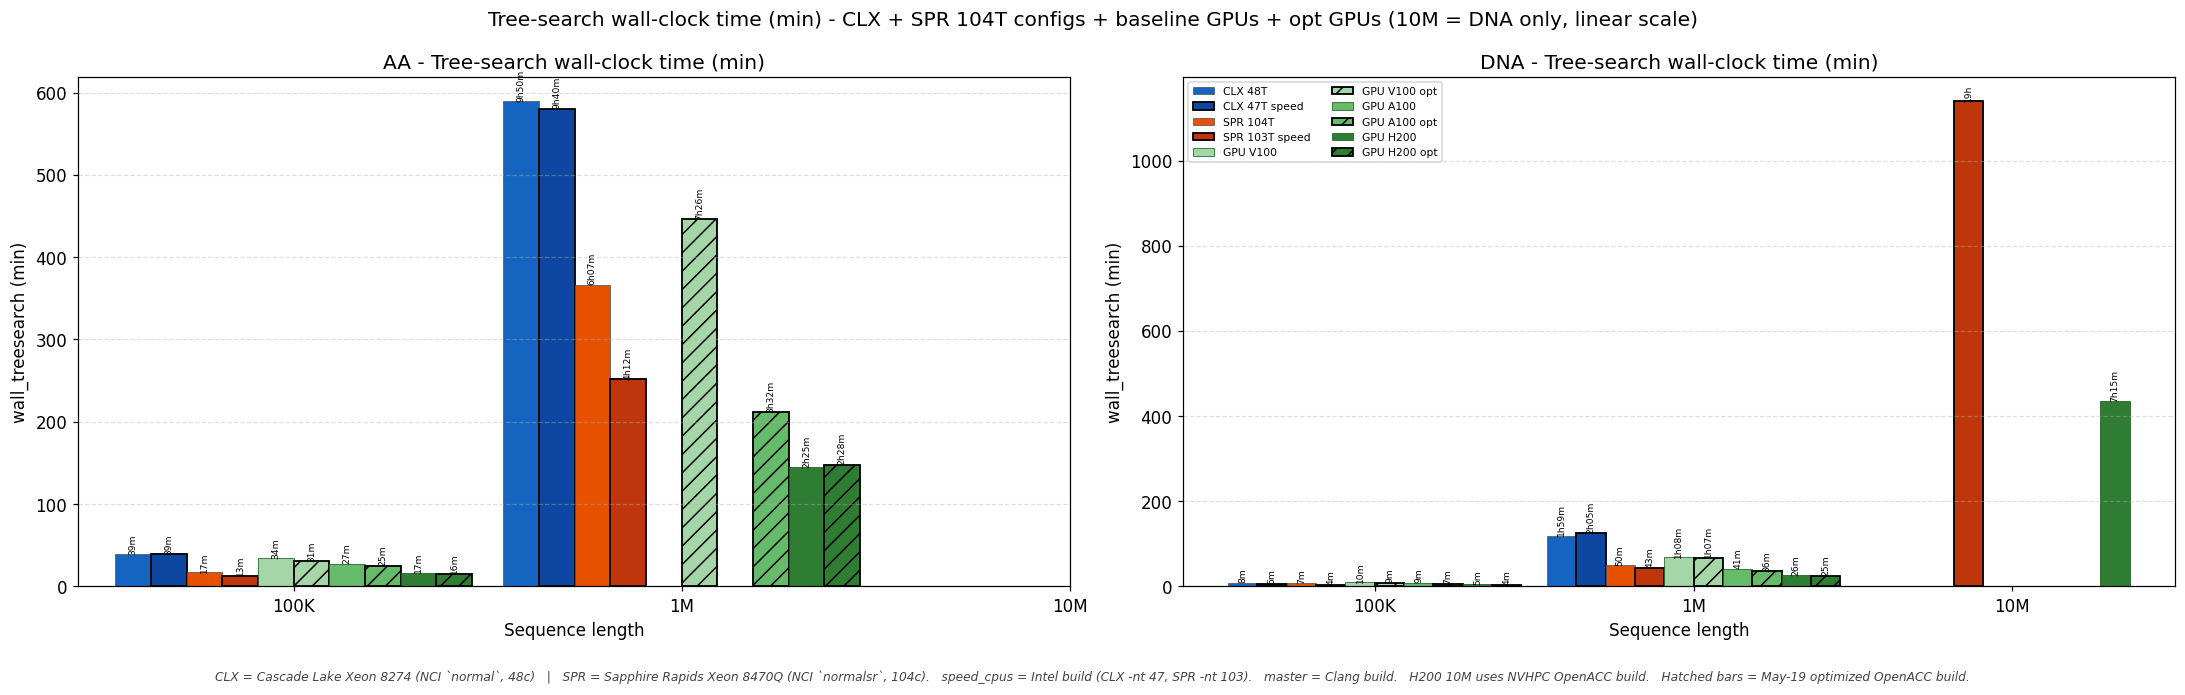

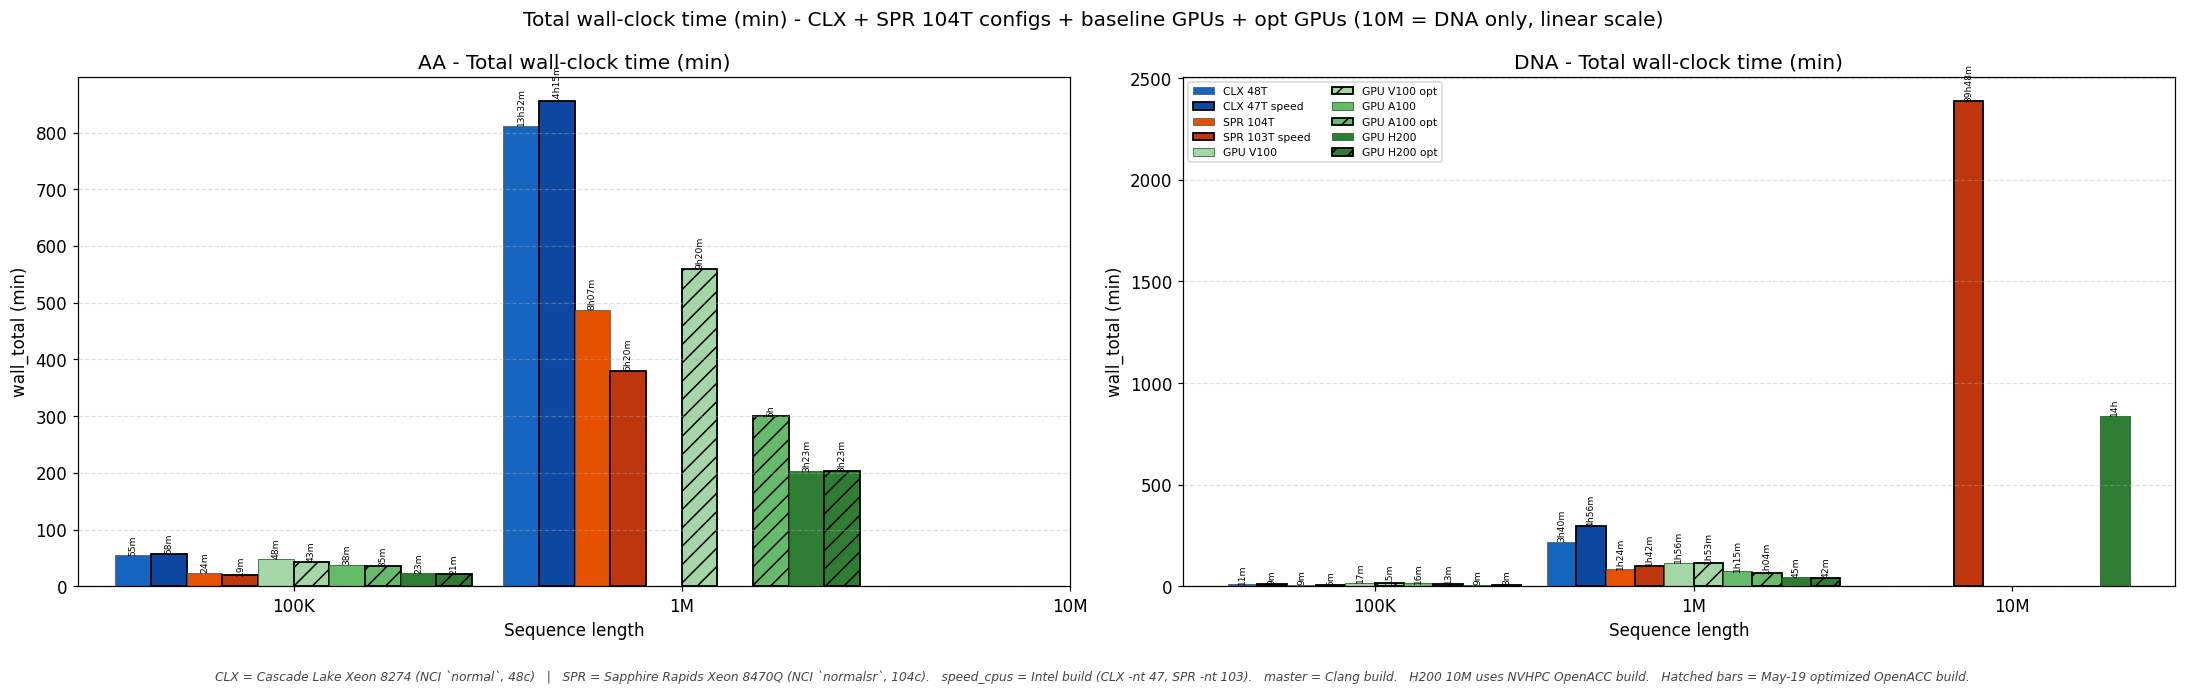

In [12]:
def fmt_min(m):
    if pd.isna(m): return ''
    if m < 1:  return f'{m*60:.0f}s'
    if m < 60: return f'{m:.0f}m'
    h, mm = divmod(int(round(m)), 60)
    return f'{h}h{mm:02d}m' if mm else f'{h}h'

LENGTHS_PLOT = [100000, 1000000, 10000000]
LEN_LABEL    = {100000: '100K', 1000000: '1M', 10000000: '10M'}

# (display_label, match_label, color, edge, hatch)
CONFIG_ORDER = [
    ('CLX 48T',         'CLX 48T',          '#1565C0', '#555', None),
    ('CLX 47T speed',   'CLX 47T (speed)',  '#0D47A1', '#000', None),
    ('SPR 104T',        'SPR 104T',         '#E65100', '#555', None),
    ('SPR 103T speed',  'SPR 103T (speed)', '#BF360C', '#000', None),
    ('GPU V100',        'GPU V100',         '#A5D6A7', '#1B5E20', None),
    ('GPU V100 opt',    'GPU V100 opt',     '#A5D6A7', '#000',    '//'),
    ('GPU A100',        'GPU A100',         '#66BB6A', '#1B5E20', None),
    ('GPU A100 opt',    'GPU A100 opt',     '#66BB6A', '#000',    '//'),
    ('GPU H200',        'GPU H200',         '#2E7D32', '#1B5E20', None),
    ('GPU H200 opt',    'GPU H200 opt',     '#2E7D32', '#000',    '//'),
]

def get_val(dt, length, config_label, col):
    r = combined[(combined['data_type']==dt) & (combined['length']==length) & (combined['config_label']==config_label)]
    return r[col].iloc[0] if len(r) and pd.notna(r[col].iloc[0]) else np.nan

FOOTNOTE = ('CLX = Cascade Lake Xeon 8274 (NCI `normal`, 48c)   |   '
            'SPR = Sapphire Rapids Xeon 8470Q (NCI `normalsr`, 104c).   '
            'speed_cpus = Intel build (CLX -nt 47, SPR -nt 103).   master = Clang build.   '
            'H200 10M uses NVHPC OpenACC build.   Hatched bars = May-19 optimized OpenACC build.')

def bars(metric_col, title, ylabel, fname, log_y=True):
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    n = len(CONFIG_ORDER)
    x = np.arange(len(LENGTHS_PLOT))
    width = 0.92 / n
    for ax, dt in zip(axes, ['AA', 'DNA']):
        for i, (label, cfg, color, edge, hatch) in enumerate(CONFIG_ORDER):
            vals = [get_val(dt, L, cfg, metric_col) for L in LENGTHS_PLOT]
            offs = x + (i - n/2 + 0.5) * width
            lw = 1.2 if ('speed' in label or 'opt' in label) else 0.5
            ax.bar(offs, vals, width, label=label, color=color, edgecolor=edge,
                   linewidth=lw, hatch=hatch)
            for bx, by in zip(offs, vals):
                if not np.isnan(by):
                    ax.text(bx, by, fmt_min(by), ha='center', va='bottom', fontsize=6, rotation=90)
        ax.set_xticks(x); ax.set_xticklabels([LEN_LABEL[L] for L in LENGTHS_PLOT])
        ax.set_xlabel('Sequence length'); ax.set_ylabel(ylabel)
        if log_y: ax.set_yscale('log')
        ax.set_title(f'{dt} - {title}')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4, which='both')
    axes[1].legend(fontsize=7, ncol=2, loc='upper left')
    scale_tag = 'log' if log_y else 'linear'
    fig.suptitle(f'{title} - CLX + SPR 104T configs + baseline GPUs + opt GPUs (10M = DNA only, {scale_tag} scale)')
    fig.tight_layout()
    fig.text(0.5, -0.02, FOOTNOTE, ha='center', va='top', fontsize=8, style='italic', color='#444')
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()

bars('wall_treesearch_min', 'Tree-search wall-clock time (log min)',
     'wall_treesearch (min, log)', 'fig_combined_treesearch.png', log_y=True)
bars('wall_total_min', 'Total wall-clock time (log min)',
     'wall_total (min, log)', 'fig_combined_wall_total.png', log_y=True)
bars('wall_treesearch_min', 'Tree-search wall-clock time (min)',
     'wall_treesearch (min)', 'fig_combined_treesearch_linear.png', log_y=False)
bars('wall_total_min', 'Total wall-clock time (min)',
     'wall_total (min)', 'fig_combined_wall_total_linear.png', log_y=False)